## 差分数组的核心使用场景信号

**最本质的一句话：** 多个区间，每个区间携带一个值，区间之间可以交叉叠加，最终求每个位置的累计结果。

---

**信号一：操作是"对某个区间统一加减一个值"**

题目中出现类似"给区间 `[l, r]` 内所有元素加上 `x`"的描述，这是差分数组最直接的触发信号。本质上就是：有一批这样的区间操作，每次操作影响的是一段连续位置。

**信号二：区间之间存在交叉或重叠**

多个区间可以互相嵌套、交叉、覆盖，每个位置的最终值是所有覆盖它的区间的叠加结果。这正是差分数组擅长处理的结构——它天然支持多区间叠加，无需逐个遍历。

**信号三：操作很多次，但只关心最终状态**

题目结构是"执行 m 次区间更新，输出最终数组"，而不是"每次更新后立即查询"。差分数组将 `O(m × n)` 的暴力做法压缩为 `O(m + n)`，规模一大几乎是唯一选择。

**信号四：输出目标是整个数组，而非区间查询**

区分三种问题类型：
- 只有区间更新，最后输出数组 → **差分数组**
- 只有区间查询（无更新）→ **前缀和**
- 区间更新 + 区间查询混合 → **线段树 / 树状数组**

---

**快速判断口诀：** 多区间更新、区间可叠加、只求最终数组、数据规模大——优先差分数组。

## 1109. 航班预订统计

这里有 n 个航班，它们分别从 1 到 n 进行编号。

有一份航班预订表 bookings ，表中第 i 条预订记录 bookings[i] = [firsti, lasti, seatsi] 意味着在从 firsti 到 lasti （包含 firsti 和 lasti ）的 每个航班 上预订了 seatsi 个座位。

请你返回一个长度为 n 的数组 answer，里面的元素是每个航班预定的座位总数。

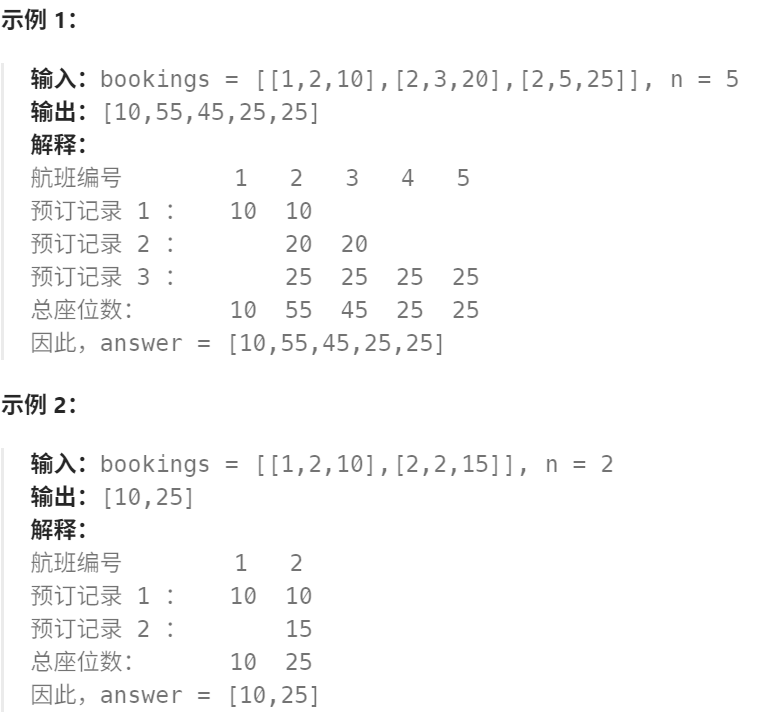

In [6]:
from typing import List

class Solution:
    def corpFlightBookings(self, bookings: List[List[int]], n: int) -> List[int]:
        
        # --- 1. 初始化差分数组 ---
        diff = [0] * n
        
        # --- 2. 处理每一个区间更新 ---
        for first, last, seats in bookings:
            
            # 注意题目下标是从 1 开始的
            diff[first - 1] += seats
            
            # 如果 last 没越界，则进行右边界减操作
            if last < n:
                diff[last] -= seats
        
        # --- 3. 还原原数组（前缀和计算） ---
        for i in range(1, n):
            diff[i] = diff[i - 1] + diff[i]
        
        return diff


# --- 使用示例 ---
bookings = [[1,2,10],[2,3,20],[2,5,25]]
n = 5

solver = Solution()
print(solver.corpFlightBookings(bookings, n))

[10, 55, 45, 25, 25]


差分数组（difference array）是一种用于**高效处理区间增量更新问题**的数据结构思想。它的核心目标是：当存在大量“对连续区间统一加减某个数值”的操作时，避免逐个元素更新，从而把时间复杂度从 $O(n \times m)$ 优化到 $O(n + m)$。

具体来说，差分数组 `diff` 的定义是：

对于原数组 `arr`，定义：

$
diff[i] = arr[i] - arr[i-1]
$

其中约定：

$
diff[0] = arr[0]
$

因此可以理解为：

**diff[i] 表示当前位置相对于前一个位置的变化量**

换句话说：

`diff` 记录的不是元素值本身，而是**变化趋势**

当对某个区间 `[l, r]` 统一加上一个数 `x` 时：

原始思路是：

```
arr[l] += x
arr[l+1] += x
...
arr[r] += x
```

需要循环更新整个区间。

而差分数组的思想是：

只记录变化开始的位置和变化结束的位置：

```
diff[l] += x
diff[r+1] -= x
```

这样就完成了整个区间更新操作。

原因在于：

当之后执行前缀和恢复数组时：

```
arr[i] = diff[0] + diff[1] + ... + diff[i]
```

变化会自动传播到整个区间。

现在解释本题中的关键语句：

```
diff[first - 1] += seats
```

它的含义是：

从航班 `first` 开始，每个航班座位数增加 `seats`

由于数组是从 0 开始编号，而题目航班编号从 1 开始编号，因此需要转换为：

```
first → first - 1
```

这一步表示：

变化从这里开始生效

接着解释：

```
diff[last] -= seats
```

它的含义是：

从航班 `last + 1` 开始，不再增加座位数

即：

终止区间影响范围

注意：

这里写的是：

```
diff[last]
```

而不是：

```
diff[last + 1]
```

原因是数组索引已经做过一次偏移：

题目：

```
[ first , last ]
```

映射到数组：

```
[ first-1 , last-1 ]
```

因此：

区间终止位置应该写成：

```
last
```

对应逻辑仍然是：

```
diff[r+1] -= x
```

只是已经完成一次坐标转换。


**整个操作的本质逻辑可以总结为：**

差分数组通过：

记录“变化从哪里开始”

以及：

记录“变化从哪里结束”

来间接表示整个区间的变化。

随后通过一次前缀和运算：

把这些变化恢复成真实数组值。

**因此算法流程本质是三步：**

第一步：

构建差分数组

第二步：

记录每次区间变化的起点和终点

第三步：

通过前缀和恢复最终结果数组

这种方法的核心优势是：

把原本需要更新整个区间的操作

转换为：

只更新两个端点位置

从而实现时间复杂度优化。


## 1094. 拼车

车上最初有 capacity 个空座位。车 只能 向一个方向行驶（也就是说，不允许掉头或改变方向）

给定整数 capacity 和一个数组 trips ,  trips[i] = [numPassengersi, fromi, toi] 表示第 i 次旅行有 numPassengersi 乘客，接他们和放他们的位置分别是 fromi 和 toi 。这些位置是从汽车的初始位置向东的公里数。

当且仅当你可以在所有给定的行程中接送所有乘客时，返回 true，否则请返回 false。

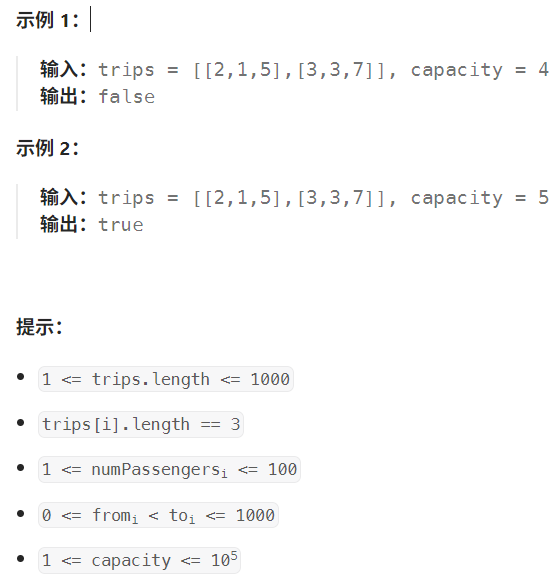

In [7]:
class Solution:
    def carPooling(self, trips: List[List[int]], capacity: int) -> bool:
        # 题目限定位置最大为 1000，直接开固定大小数组更简洁.或者找到最大终点
        diff = [0] * 1001

        for num, start, end in trips:
            diff[start] += num
            diff[end] -= num      # 到达终点即下车，end 处不再占座

        current = 0
        for passengers in diff:
            current += passengers
            if current > capacity:
                return False
        return True
trips =[[2, 1, 5], [3, 3, 7]]
capacity = 4
print(Solution().carPooling(trips, capacity))

False


核心思想
本题是差分数组的直接应用。每一趟行程可以抽象为：在区间 [from, to) 内，车上乘客数增加 num。多个行程的区间可以交叉叠加，最终只需判断每个位置的乘客总数是否超过 capacity，符合差分数组的所有使用信号。
与航班预订问题的关键区别在于：乘客在 to 位置下车，因此影响范围是左闭右开区间 [from, to)，即在 from 处 +num，在 to 处 -num（而非 to+1）。